In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from behave_analysis.analyze.filtering_data.filtering_functions import filter_video_dataframe

In [2]:
%matplotlib inline

In [3]:
# JAL1 SEQ3
JAL1_SEQ3_video_df = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_3_2023_03_17T08_38_03\processed_data\full_video_dataframe.csv"
seq3_video_df = pl.read_csv(JAL1_SEQ3_video_df)

# JAL1 SEQ2
JAL1_SEQ2_video_df = r"Z:\Jasmine_Laurence\Experimental_Data\JAL001\001_seq1_2_2023_03_14T08_11_32\processed_data\full_video_dataframe.csv" 
seq2_video_df = pl.read_csv(JAL1_SEQ2_video_df)

# JAL2 SEQ2
JAL2_SEQ2_video_df =  r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_seq1_2_2023_04_25T07_32_30\processed_data\full_video_dataframe.csv"
jal2_seq2_df = pl.read_csv(JAL2_SEQ2_video_df)

# JAl2 SEQ3
JAL2_SEQ3_video_df =  r"Z:\Jasmine_Laurence\Experimental_Data\JAL002\002_Sequence1_3_2023_04_28T08_31_30\processed_data\full_video_dataframe.csv"
jal2_seq3_df = pl.read_csv(JAL2_SEQ3_video_df)

In [ ]:
jal2_seq3_df.columns

# Two edge task unvisited areas 

In [ ]:


# Arena parameters
arena_radius = 460  # pixels (1 pixel = 1 cm)
arena_size = 1024  # size of the arena (1024x1024 pixels)

sessions = {
    "JAL1_SEQ3": seq3_video_df,
    "JAL1_SEQ2": seq2_video_df,
    "JAL2_SEQ2": jal2_seq2_df,
    "JAL2_SEQ3": jal2_seq3_df,
}

def quantify_arena_coverage(video_df, arena_radius, arena_size, bins=100):
    """Quantify gaps in arena coverage for a single session."""
    # Extract mouse positions
    x_positions = video_df["mouse_x_position"].to_numpy()
    y_positions = video_df["mouse_y_position"].to_numpy()

    # Create a 2D histogram of visited positions with larger bins
    hist, x_edges, y_edges = np.histogram2d(
        x_positions, y_positions, bins=bins, range=[[0, arena_size], [0, arena_size]]
    )

    # Create a mask for the circular arena
    y, x = np.ogrid[:bins, :bins]
    center = bins // 2
    mask = (x - center)**2 + (y - center)**2 <= (arena_radius / (arena_size / bins))**2

    # Calculate visited pixels
    visited = hist > 0
    visited_area = np.sum(visited & mask)

    # Calculate total area of the arena
    total_area = np.sum(mask)

    # Calculate unvisited area
    unvisited_area = total_area - visited_area

    # Divide the arena into quadrants and calculate unvisited area for each
    quadrants = {
        "top-left": mask & (x < center) & (y < center),
        "top-right": mask & (x >= center) & (y < center),
        "bottom-left": mask & (x < center) & (y >= center),
        "bottom-right": mask & (x >= center) & (y >= center),
    }
    quadrant_unvisited = {q: np.sum((~visited) & quadrants[q]) for q in quadrants}

    # Calculate percentages
    unvisited_percentage = (unvisited_area / total_area) * 100
    quadrant_percentages = {q: (quadrant_unvisited[q] / np.sum(quadrants[q])) * 100 for q in quadrants}

    return unvisited_percentage, quadrant_percentages

# Quantify coverage for all sessions
results = {}
for session_name, video_df in sessions.items():
    unvisited_percentage, quadrant_percentages = quantify_arena_coverage(video_df, arena_radius, arena_size, bins=100)
    results[session_name] = {
        "unvisited_percentage": unvisited_percentage,
        "quadrant_percentages": quadrant_percentages,
    }

# Aggregate quadrant percentages across sessions
quadrants = ["top-left", "top-right", "bottom-left", "bottom-right"]
quadrant_data = {q: [] for q in quadrants}

for session_name, data in results.items():
    for q in quadrants:
        quadrant_data[q].append(data["quadrant_percentages"][q])

# Calculate mean and SEM for each quadrant
means = [np.mean(quadrant_data[q]) for q in quadrants]
sems = [np.std(quadrant_data[q], ddof=1) / np.sqrt(len(quadrant_data[q])) for q in quadrants]

# Plot aggregated data
plt.rcParams.update({
    "font.size": 18,
    "font.family": "Arial",
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(quadrants))
bar_width = 0.6

# Plot bars with error bars
ax.bar(x, means, yerr=sems, capsize=5, color="lightgrey", edgecolor="black", linewidth=1.5, width=bar_width)

# Add crosses for individual session data points
for i, q in enumerate(quadrants):
    for val in quadrant_data[q]:
        ax.plot(i, val, marker='x', color='black', markersize=10, markeredgewidth=1.5)

# Add labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(quadrants)
ax.set_ylabel("Unvisited Area (%)")
ax.set_xlabel("Quadrants")
ax.set_title("Unvisited Arena Coverage by Quadrant")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)
ax.tick_params(width=1.5, length=6)
plt.tight_layout()
plt.show()
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
fig.savefig(os.path.join(save_path, "two_edge_quandrant_coverage.eps"), format='eps', bbox_inches='tight', dpi=300)

# Explainer diagram for the quandrants

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Arena parameters
arena_radius = 460  # pixels (1 pixel = 1 cm)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(6, 6))

# Draw the circular arena
circle = plt.Circle((0, 0), arena_radius, color="lightgrey", alpha=0.5, edgecolor="black", linewidth=1.5)
ax.add_artist(circle)

# Draw quadrant dividing lines
ax.plot([-arena_radius, arena_radius], [0, 0], color="black", linewidth=1.5)  # Horizontal line
ax.plot([0, 0], [-arena_radius, arena_radius], color="black", linewidth=1.5)  # Vertical line

# Label quadrants
ax.text(-arena_radius / 2, arena_radius / 2, "Top-Left", fontsize=16, ha="center", va="center", fontweight="bold")
ax.text(arena_radius / 2, arena_radius / 2, "Top-Right", fontsize=16, ha="center", va="center", fontweight="bold")
ax.text(-arena_radius / 2, -arena_radius / 2, "Bottom-Left", fontsize=16, ha="center", va="center", fontweight="bold")
ax.text(arena_radius / 2, -arena_radius / 2, "Bottom-Right", fontsize=16, ha="center", va="center", fontweight="bold")

# Set axis limits and aspect ratio
ax.set_xlim(-arena_radius - 50, arena_radius + 50)
ax.set_ylim(-arena_radius - 50, arena_radius + 50)
ax.set_aspect("equal", adjustable="datalim")

# Remove axis ticks and labels
ax.axis("off")

# Add title
ax.set_title("Arena Quadrants", fontsize=20, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(save_path, "quandrant_explainer.eps"), format='eps', bbox_inches='tight', dpi=300)

In [ ]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept
from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept
from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept
from behave_analysis.database.Experiments.JAL006_ex import JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr
from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr, JAL7_30apr
from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_tiny_3may, JAL8_flip4_10may, JAL8_14may, JAL8_21may

In [ ]:
experiments_objects = [JAL6_flip7_1apr, JAL6_flip3_18mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_28mar,
                       JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept,
                       JAL005_8thSept, JAL005_21stSept,
                       JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr,
                       JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may,
                       JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept]

# Comparison of two edge vs one edge quandrant coverage

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from behave_analysis.process.session import get_experiment

# Arena parameters
arena_radius = 460  # pixels (1 pixel = 1 cm)
arena_size = 1024  # size of the arena (1024x1024 pixels)
bins = 100  # Number of bins for histogram

# Two-edge sessions
two_edge_sessions = {
    "JAL1_SEQ3": seq3_video_df,
    "JAL1_SEQ2": seq2_video_df,
    "JAL2_SEQ2": jal2_seq2_df,
    "JAL2_SEQ3": jal2_seq3_df,
}

# Function to quantify arena coverage
def quantify_arena_coverage(video_df, arena_radius, arena_size, bins=100):
    """Quantify gaps in arena coverage for a single session."""
    # Extract mouse positions
    x_positions = video_df["mouse_x_position"].to_numpy()
    y_positions = video_df["mouse_y_position"].to_numpy()

    # Create a 2D histogram of visited positions
    hist, x_edges, y_edges = np.histogram2d(
        x_positions, y_positions, bins=bins, range=[[0, arena_size], [0, arena_size]]
    )

    # Create a mask for the circular arena
    y, x = np.ogrid[:bins, :bins]
    center = bins // 2
    mask = (x - center)**2 + (y - center)**2 <= (arena_radius / (arena_size / bins))**2

    # Calculate visited pixels
    visited = hist > 0
    visited_area = np.sum(visited & mask)

    # Calculate total area of the arena
    total_area = np.sum(mask)

    # Divide the arena into quadrants and calculate unvisited area for each
    quadrants = {
        "top-left": mask & (x < center) & (y < center),
        "top-right": mask & (x >= center) & (y < center),
        "bottom-left": mask & (x < center) & (y >= center),
        "bottom-right": mask & (x >= center) & (y >= center),
    }
    quadrant_unvisited = {q: np.sum((~visited) & quadrants[q]) for q in quadrants}

    # Calculate percentages
    quadrant_percentages = {q: (quadrant_unvisited[q] / np.sum(quadrants[q])) * 100 for q in quadrants}

    return quadrant_percentages

# Calculate quadrant percentages for two-edge sessions
two_edge_quadrant_data = {q: [] for q in ["top-left", "top-right", "bottom-left", "bottom-right"]}
for session_name, video_df in two_edge_sessions.items():
    quadrant_percentages = quantify_arena_coverage(video_df, arena_radius, arena_size, bins)
    for q in quadrant_percentages:
        two_edge_quadrant_data[q].append(quadrant_percentages[q])

# Calculate quadrant percentages for one-edge task (experimental objects)
one_edge_quadrant_data = {q: [] for q in ["top-left", "top-right", "bottom-left", "bottom-right"]}
for session in experiments_objects:
    loaded_session = get_experiment(session)
    video_df_path = os.path.join(
        loaded_session.base_path,
        loaded_session.processed_path,
        "full_video_dataframe.csv"
    )
    if os.path.exists(video_df_path):
        video_df = pl.read_csv(video_df_path)
        quadrant_percentages = quantify_arena_coverage(video_df, arena_radius, arena_size, bins)
        for q in quadrant_percentages:
            one_edge_quadrant_data[q].append(quadrant_percentages[q])

# Calculate mean and SEM for each quadrant for both groups
quadrants = ["top-left", "top-right", "bottom-left", "bottom-right"]
two_edge_means = [np.mean(two_edge_quadrant_data[q]) for q in quadrants]
two_edge_sems = [np.std(two_edge_quadrant_data[q], ddof=1) / np.sqrt(len(two_edge_quadrant_data[q])) for q in quadrants]
one_edge_means = [np.mean(one_edge_quadrant_data[q]) for q in quadrants]
one_edge_sems = [np.std(one_edge_quadrant_data[q], ddof=1) / np.sqrt(len(one_edge_quadrant_data[q])) for q in quadrants]

# Plot comparison
plt.rcParams.update({
    "font.size": 18,
    "font.family": "Arial",
    "axes.labelsize": 20,
    "axes.titlesize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16,
})

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(quadrants))
bar_width = 0.35

# Plot bars for two-edge sessions
ax.bar(
    x - bar_width/2, two_edge_means, yerr=two_edge_sems, width=bar_width,
    color="dimgrey", label="Two-Edge Sessions", capsize=5, edgecolor='black', linewidth=1.5
)

# Plot bars for one-edge task
ax.bar(
    x + bar_width/2, one_edge_means, yerr=one_edge_sems, width=bar_width,
    color="lightgrey", label="One-Edge Task", capsize=5, edgecolor='black', linewidth=1.5
)

# Add labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(quadrants)
ax.set_ylabel("Unvisited Area (%)")
ax.set_xlabel("Quadrants")
ax.set_title("Comparison of Unvisited Arena Coverage by Quadrant")
ax.legend(facecolor="white", frameon=False, loc='upper left')
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)
ax.tick_params(width=1.5, length=6)
plt.tight_layout()

# Save figure as EPS for publication
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
fig.savefig(os.path.join(save_path, "quadrant_coverage_comparison.eps"), format='eps', bbox_inches='tight', dpi=300)
plt.show()

# montey carlo simulations

In [ ]:
"""
Quick demo: exploration coverage ↓ → statistical power ↓

Keeps runtime low (~30 s) yet yields a clean, downward curve.
Requires: numpy, matplotlib, astropy      pip install astropy
"""

# ------------------------------------------------------------------
# USER KNOBS
# ------------------------------------------------------------------
BINS          = 80
N_SAMPLES     = 5_000
KAPPA_BASE    = 2.5          # maximum κ at full coverage
ALPHA_LEVEL   = 0.05


N_PATTERNS    = 10           # gap layouts averaged
N_ITER        = 500          # sessions per gap layout
N_PERM        = 499          # permutations per session
RNG_SEED      = 1337
# ------------------------------------------------------------------

import numpy as np, matplotlib.pyplot as plt
from numpy.random import default_rng
from astropy.stats import circstats

# ---------- helpers ----------
def arena_mask(bins, r_px=460, size_px=1024):
    y,x = np.ogrid[:bins,:bins]; c=bins//2
    r   = r_px / (size_px / bins)
    return (x-c)**2 + (y-c)**2 <= r**2

def gaps(mask, frac, rng):
    idx = np.flatnonzero(mask); M=len(idx); k=int(round(frac*M))
    p = np.zeros(M); 
    if k<M:
        p.fill(1/(M-k))
        if k: p[rng.choice(M,k,False)] = 0
    return p

def pval(alpha,beta,n_perm,rng):
    r_obs = circstats.circcorrcoef(alpha,beta)
    geq=0
    for _ in range(n_perm):
        if circstats.circcorrcoef(alpha,rng.permutation(beta))>=r_obs: geq+=1
    return (geq+1)/(n_perm+1)

def power(p_visit,theta,n_samp,kappa,alpha,n_iter,n_perm,rng):
    M=len(p_visit); sig=0
    for _ in range(n_iter):
        bins = rng.choice(M,n_samp,p=p_visit)
        a    = theta[bins]
        b    = (a + rng.vonmises(0,kappa,n_samp))%(2*np.pi)
        sig += pval(a,b,n_perm,rng) < alpha
    return sig/n_iter

# ---------- sweep ----------
rng  = default_rng(RNG_SEED)
mask = arena_mask(BINS)
idx  = np.flatnonzero(mask)
y,x  = np.divmod(idx,BINS); c=BINS//2
theta= np.mod(np.arctan2(y-c,x-c),2*np.pi)

fracs = np.linspace(0,0.9,10)
mean_pow, sem_pow = [], []

for f in fracs:
    reps=[]
    for _ in range(N_PATTERNS):
        p = gaps(mask,f,rng)
        κ = KAPPA_BASE*(1-f)          # <-- key line : weaker corr when coverage poor
        reps.append(power(p,theta,N_SAMPLES,κ,ALPHA_LEVEL,
                          N_ITER,N_PERM,rng))
    reps=np.asarray(reps)
    mean_pow.append(reps.mean()); sem_pow.append(reps.std(ddof=1)/np.sqrt(N_PATTERNS))
    print(f"{f:4.1%} unvisited → {reps.mean()*100:6.2f}% ±{sem_pow[-1]*100:4.1f} pp")

# ---------- plot ----------
plt.rcParams.update({"font.size":14,"axes.linewidth":1.2})
fig,ax=plt.subplots(figsize=(7,5))
ax.errorbar(fracs*100,np.array(mean_pow)*100,
            yerr=np.array(sem_pow)*100,marker='o',lw=2,capsize=4)
ax.set(xlabel="Fraction UNVISITED (%)",
       ylabel="Statistical power (P < 0.05)  [%]",
       title="Less exploration ⇒ lower detection power")
ax.set_xlim(0,90); ax.set_ylim(0,100); ax.grid(ls='--',alpha=.4)
plt.tight_layout(); plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import default_rng
from astropy.stats import circstats

"""
Monte Carlo bias analysis of circular correlations under under‑sampling.

This script:
 1. Loads "optimal" distributions of angles from CSV (true, full‑coverage correlations).
 2. Computes the true circular correlation for each angle pair.
 3. For each under‑sampling fraction:
    • Repeats many random drop‑out patterns of rows (simulating exploration gaps).
    • Computes circular correlation on each down‑sampled dataset.
    • Records the mean and SEM of resulting correlations.
 4. Plots how the observed correlation drifts away from the true value as coverage decreases.

Dependencies:
  • numpy, pandas, matplotlib, astropy
  • pip install astropy

Usage:
  • Place `optimal_distributions.csv` in working directory.
  • Adjust USER PARAMETERS as needed, then run with Python.
"""

# ------------------------------------------------------------------
# USER PARAMETERS
# ------------------------------------------------------------------
CSV_PATH      = "optimal_distributions.csv"  # path to your optimal CSV
ANGLE_PAIRS   = [                          # list of column‑pairs to analyze
    ("hdir", "hsa"),
    ("hdir", "h_postflipbar_a"),
    ("hdir", "h_preflipbar_a"),
    ("hsa",  "h_postflipbar_a"),
    ("hsa",  "h_preflipbar_a"),
    ("h_postflipbar_a", "h_preflipbar_a")
]
FRACS         = np.linspace(0.0, 0.9, 10)   # fractions of rows to DROP (unvisited)
N_REPS        = 50                         # Monte Carlo repetitions per fraction
RNG_SEED      = 1337                       # reproducible randomness

# ------------------------------------------------------------------
# LOAD OPTIMAL DATA
# ------------------------------------------------------------------
# Each column in CSV_PATH holds angle values (radians) under full coverage
df = pd.read_csv(CSV_PATH)

# Initialize RNG
gen = default_rng(RNG_SEED)

# Compute true (full‑coverage) correlations
true_rhos = {}
for a, b in ANGLE_PAIRS:
    alpha = df[a].to_numpy()
    beta  = df[b].to_numpy()
    true_rhos[(a,b)] = circstats.circcorrcoef(alpha, beta)

# ------------------------------------------------------------------
# MONTE CARLO UNDER‑SAMPLING
# ------------------------------------------------------------------
# For each drop fraction, simulate N_REPS drop‑outs and measure rho drift
results = { (a,b): { 'mean': [], 'sem': [] } for (a,b) in ANGLE_PAIRS }

for frac in FRACS:
    for (a,b) in ANGLE_PAIRS:
        sample_rhos = []
        for rep in range(N_REPS):
            # randomly drop `frac` of rows → keep 1‑frac fraction
            sub = df.sample(frac=1-frac, random_state=gen.integers(1e9))
            alpha_sub = sub[a].to_numpy()
            beta_sub  = sub[b].to_numpy()
            # compute correlation on undersampled data
            rho_sub = circstats.circcorrcoef(alpha_sub, beta_sub)
            sample_rhos.append(rho_sub)
        arr = np.array(sample_rhos)
        # record mean and SEM of sampled correlations
        results[(a,b)]['mean'].append(arr.mean())
        results[(a,b)]['sem'].append(arr.std(ddof=1)/np.sqrt(N_REPS))
    print(f"Drop {frac*100:.0f}% → done")

# ------------------------------------------------------------------
# PLOT RESULTS
# ------------------------------------------------------------------
fig, axes = plt.subplots(len(ANGLE_PAIRS), 1, figsize=(8, 4*len(ANGLE_PAIRS)), sharex=True)
for idx, (a,b) in enumerate(ANGLE_PAIRS):
    ax = axes[idx]
    x = FRACS * 100
    mean_vals = np.array(results[(a,b)]['mean'])
    sem_vals  = np.array(results[(a,b)]['sem'])
    # plot true full‑coverage value as horizontal
    ax.axhline(true_rhos[(a,b)], color='gray', linestyle='--', label='True (full coverage)')
    # plot sampled mean ± SEM
    ax.errorbar(x, mean_vals, yerr=sem_vals, marker='o', capsize=3,
                label=f'{a} vs {b}')
    ax.set_ylabel('Circular ρ')
    ax.legend(loc='best')
    ax.grid(ls='--', alpha=0.4)

axes[-1].set_xlabel('Fraction of data DROPPED (%)')
fig.suptitle('Monte Carlo Drift of Circular Correlation under Under‑Sampling', fontsize=16)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


# Provide a single example of how under-sampling effects circular correlation coefficient

Drop 0% → done
Drop 10% → done
Drop 20% → done
Drop 30% → done
Drop 40% → done
Drop 50% → done
Drop 60% → done
Drop 70% → done
Drop 80% → done
Drop 90% → done


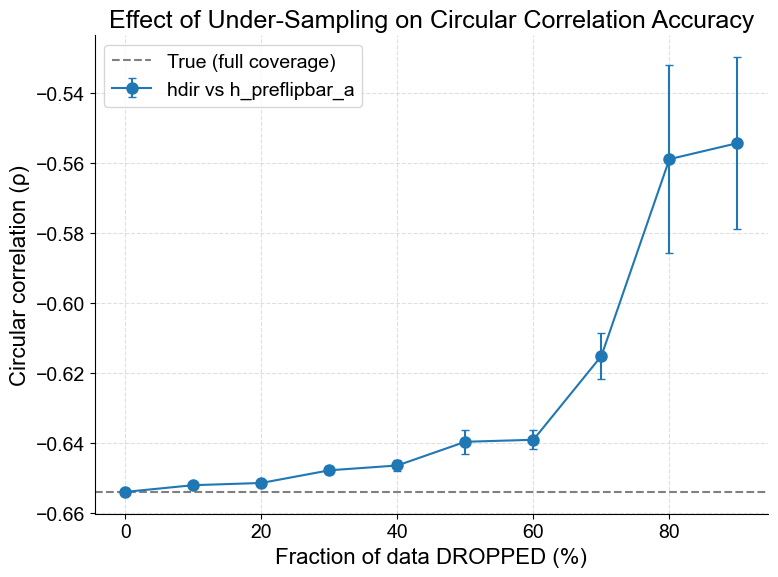

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import default_rng
from astropy.stats import circstats

# USER PARAMETERS
CSV_PATH = "optimal_distributions.csv"
ANGLE_PAIR = ("hdir", "h_preflipbar_a")  # Showing only this specific pair
FRACS = np.linspace(0.0, 0.9, 10)   # fractions of rows to DROP (unvisited)
N_REPS = 50                         # Monte Carlo repetitions per fraction
RNG_SEED = 1337                     # reproducible randomness

# LOAD OPTIMAL DATA
df = pd.read_csv(CSV_PATH)
gen = default_rng(RNG_SEED)

# Compute true (full‑coverage) correlation for just this pair
a, b = ANGLE_PAIR
alpha = df[a].to_numpy()
beta = df[b].to_numpy()
true_rho = circstats.circcorrcoef(alpha, beta)

# MONTE CARLO UNDER‑SAMPLING
means, sems = [], []

for frac in FRACS:
    sample_rhos = []
    for rep in range(N_REPS):
        # randomly drop `frac` of rows → keep 1‑frac fraction
        sub = df.sample(frac=1-frac, random_state=gen.integers(1e9))
        alpha_sub = sub[a].to_numpy()
        beta_sub = sub[b].to_numpy()
        
        # compute correlation on undersampled data
        rho_sub = circstats.circcorrcoef(alpha_sub, beta_sub)
        sample_rhos.append(rho_sub)
        
    arr = np.array(sample_rhos)
    means.append(arr.mean())
    sems.append(arr.std(ddof=1)/np.sqrt(N_REPS))
    print(f"Drop {frac*100:.0f}% → done")

# PLOT RESULT
plt.rcParams.update({
    "font.size": 14,
    "font.family": "Arial",
    "axes.labelsize": 16,
    "axes.titlesize": 16
})

fig, ax = plt.subplots(figsize=(8, 6))
x = FRACS * 100

# Plot true full‑coverage value as horizontal
ax.axhline(true_rho, color='gray', linestyle='--', label='True (full coverage)')

# Plot sampled mean ± SEM
ax.errorbar(x, means, yerr=sems, marker='o', capsize=3, markersize=8, 
           color='#1f77b4', label=f'{a} vs {b}')

ax.set_ylabel('Circular correlation (ρ)')
ax.set_xlabel('Fraction of data DROPPED (%)')
ax.set_title('Effect of Under-Sampling on Circular Correlation Accuracy', fontsize=18)
ax.legend(loc='best')
ax.grid(ls='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [5]:
# Save the figure as EPS for publication
save_path = r"Z:\Laurence\thesis\figures\two_edge_paradigm"
fig.savefig(os.path.join(save_path, "under_sampling_circular_correlation.eps"), format='eps', bbox_inches='tight', dpi=300)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
